# Import

In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Domain & Period

In [2]:
iyear=1960
fyear=2025
dom='HMA'

In [3]:
tcwv = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/FLH_monthly_era5_1940-2025_MA_025x025.nc')
tcwv = tcwv.sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

In [4]:
#focus on Middle Asia (HMA)
tcwv_MA = field_dom(tcwv,dom)

# Annual Mean

In [6]:
tcwv_mean = tcwv_MA['FLH'].mean(dim='time', skipna=True)

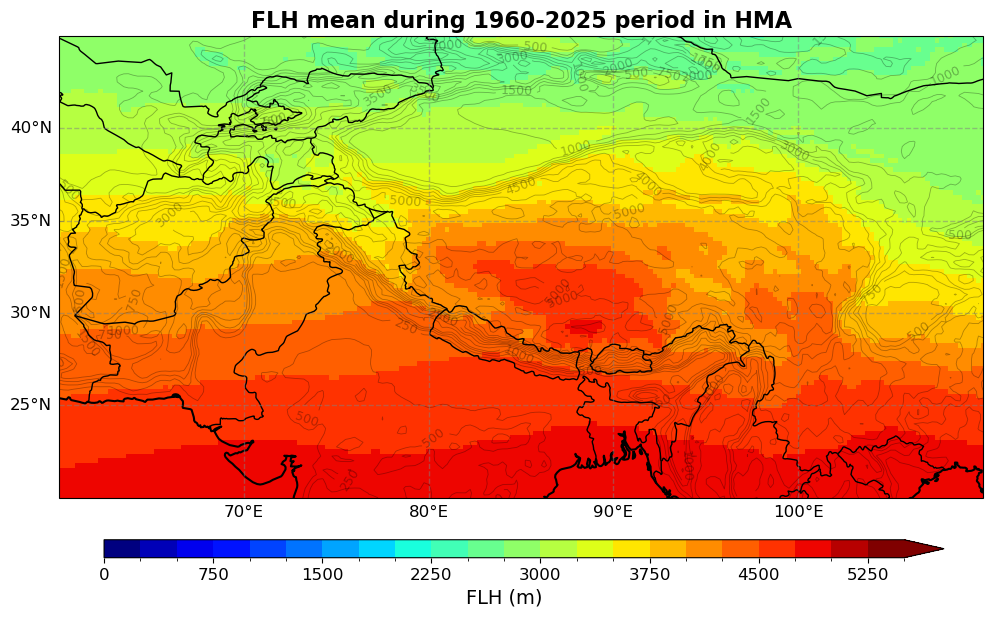

In [6]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

#tcwv color definition
vmax=5750
#vmax=tcwv_mean.max()
levels = np.arange(0, vmax, 250)
cmap = plt.get_cmap("jet", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)
pcm = ax.pcolormesh(
    tcwv_mean['lon'], tcwv_mean['lat'], tcwv_mean,
    cmap=cmap, norm=norm,transform=ccrs.PlateCarree())

#Map limitations
ax.set_extent([
    float(tcwv_mean.lon.min()),
    float(tcwv_mean.lon.max()),
    float(tcwv_mean.lat.min()),
    float(tcwv_mean.lat.max())
], crs=ccrs.PlateCarree())

#Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1)

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

#Legends
cbar_ax = fig.add_axes([0.165, 0.01, 0.7, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("FLH (m)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.set_title(f"FLH mean during {iyear}-{fyear} period in {dom}", fontsize=16, weight='bold')

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'tcwv_mean_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Climatology of tcwv

In [7]:
#Group by month + mean
monthly_clim = tcwv_MA.groupby('time.month').mean('time', skipna=True)['FLH']

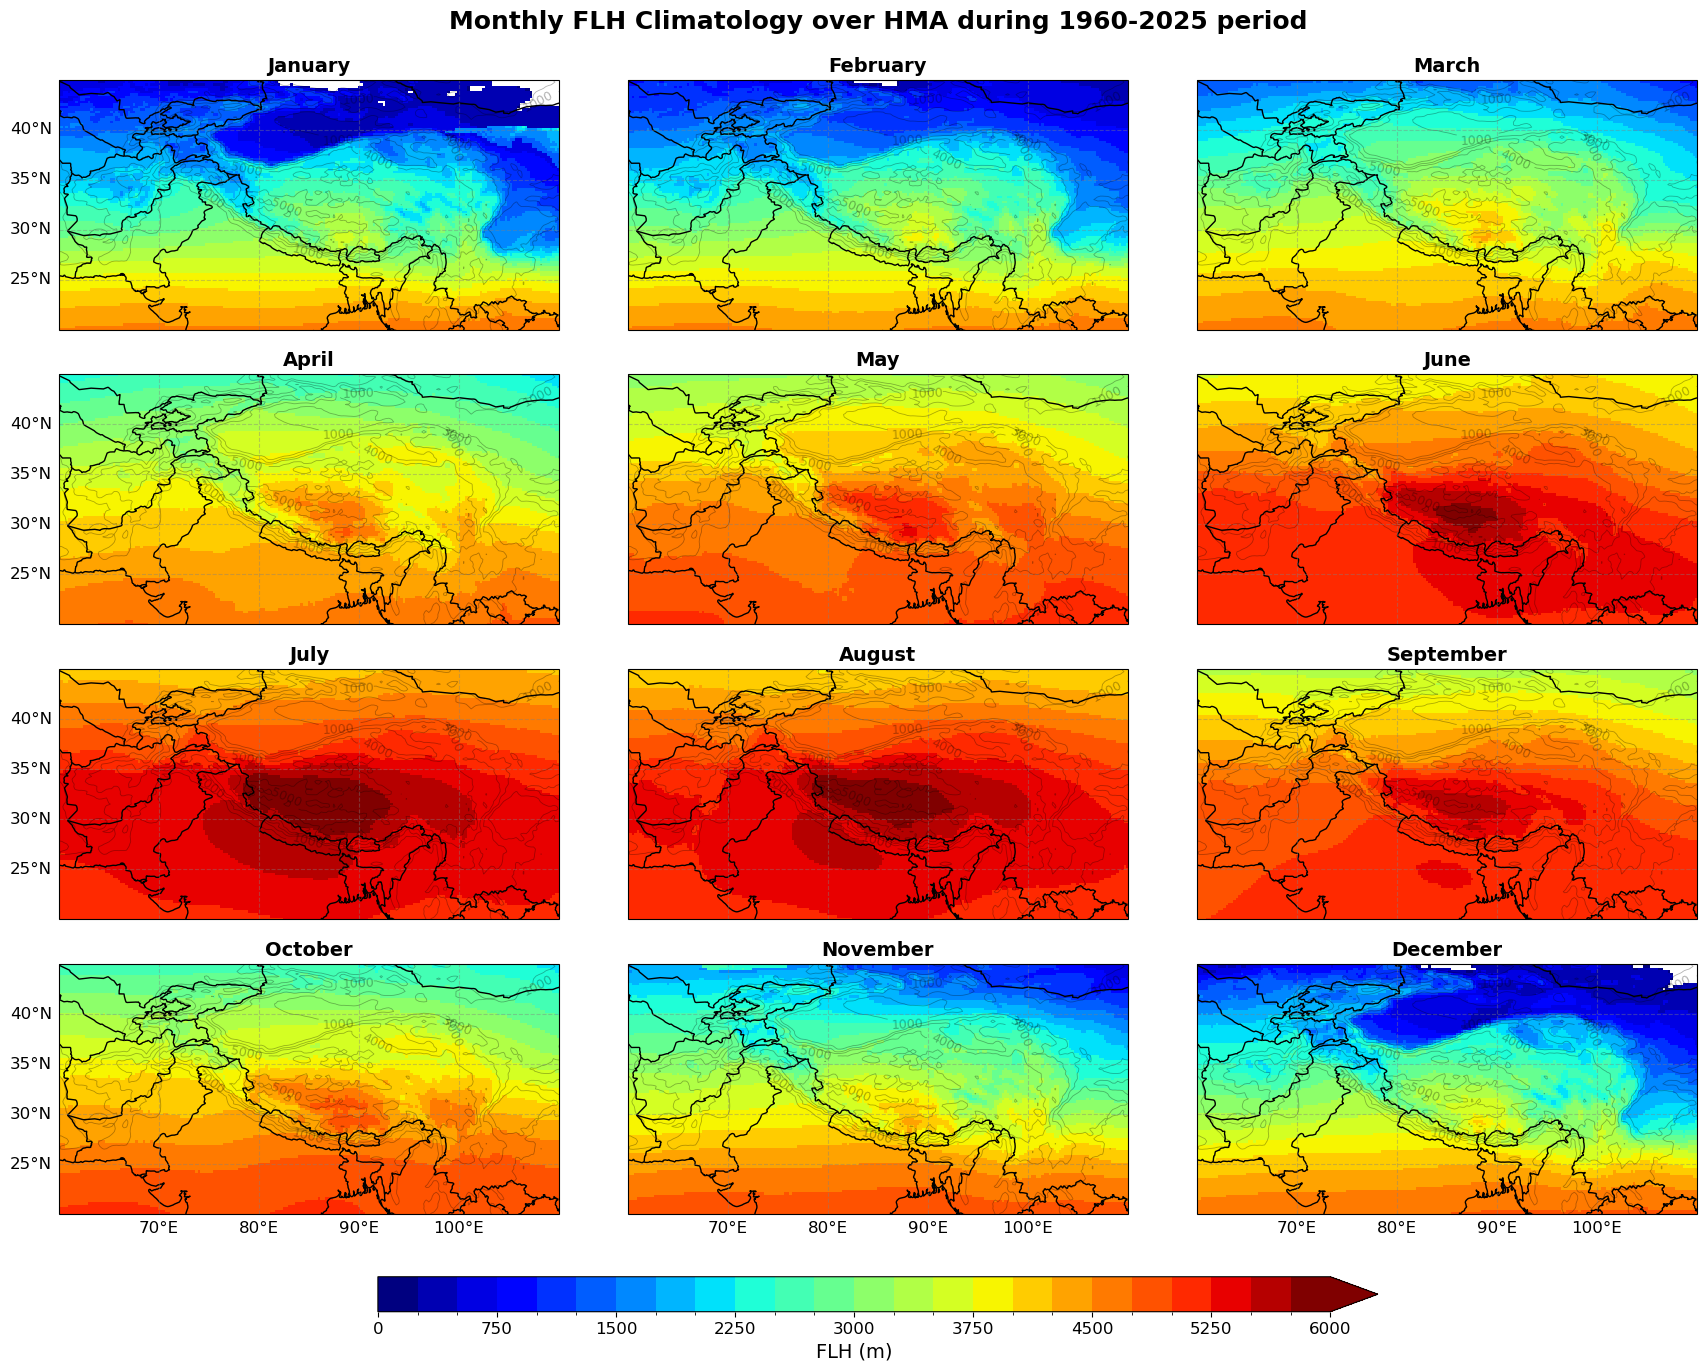

In [8]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

vmax=6250
#vmax = float(monthly_clim.max())
levels = np.arange(0, vmax, 250)
cmap = plt.get_cmap("jet")
norm = mcolors.BoundaryNorm(levels, cmap.N)

fig, axes = plt.subplots(4, 3,figsize=(20, 14),subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    data_month = monthly_clim.sel(month=i+1)
    im = ax.pcolormesh(data_month.lon,data_month.lat,data_month,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.lon.min()),
        float(tcwv_mean.lon.max()),
        float(tcwv_mean.lat.min()),
        float(tcwv_mean.lat.max())
    ], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[1000,2000,3000,4000,5000,6000,7000],
                    colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(calendar.month_name[i+1],fontsize=14,weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9)
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("FLH (m)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08,right=0.92,top=0.93,bottom=0.12,wspace=0.05,hspace=0.18)
plt.suptitle(f"Monthly FLH Climatology over {dom} during {iyear}-{fyear} period",fontsize=18,weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_clim_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Climatology of tcwv

In [9]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
clim_dict = {}

#Climatology for each season
for season in seasons:
    clim_season = clim(tcwv_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    clim_dict[season] = clim_season

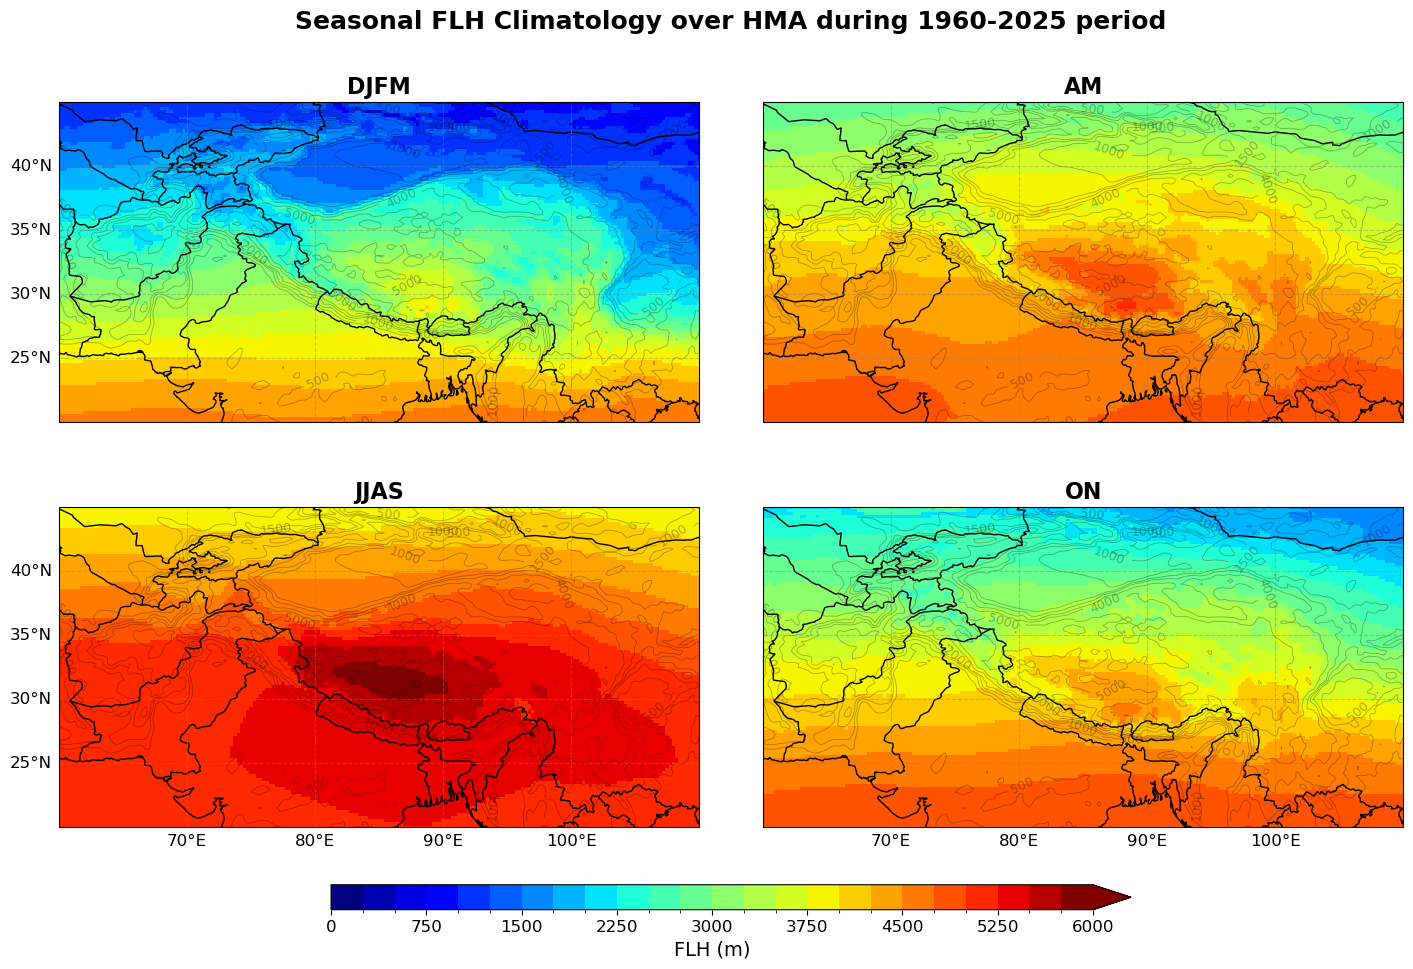

In [10]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
vmin = 0
vmax = 6250
#vmax = max(ds["tcwv"].max().item() for ds in clim_dict.values())
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

levels = np.arange(vmin, vmax, 250)
cmap = plt.get_cmap("jet")
norm = mcolors.BoundaryNorm(levels, cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = clim_dict[season]['FLH']

    im = ax.pcolormesh(data_season.lon,data_season.lat,data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.lon.min()),
        float(tcwv_mean.lon.max()),
        float(tcwv_mean.lat.min()),
        float(tcwv_mean.lat.max())
    ], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,1500,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("FLH (m)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal FLH Climatology over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'seasonal_tcwv_clim_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

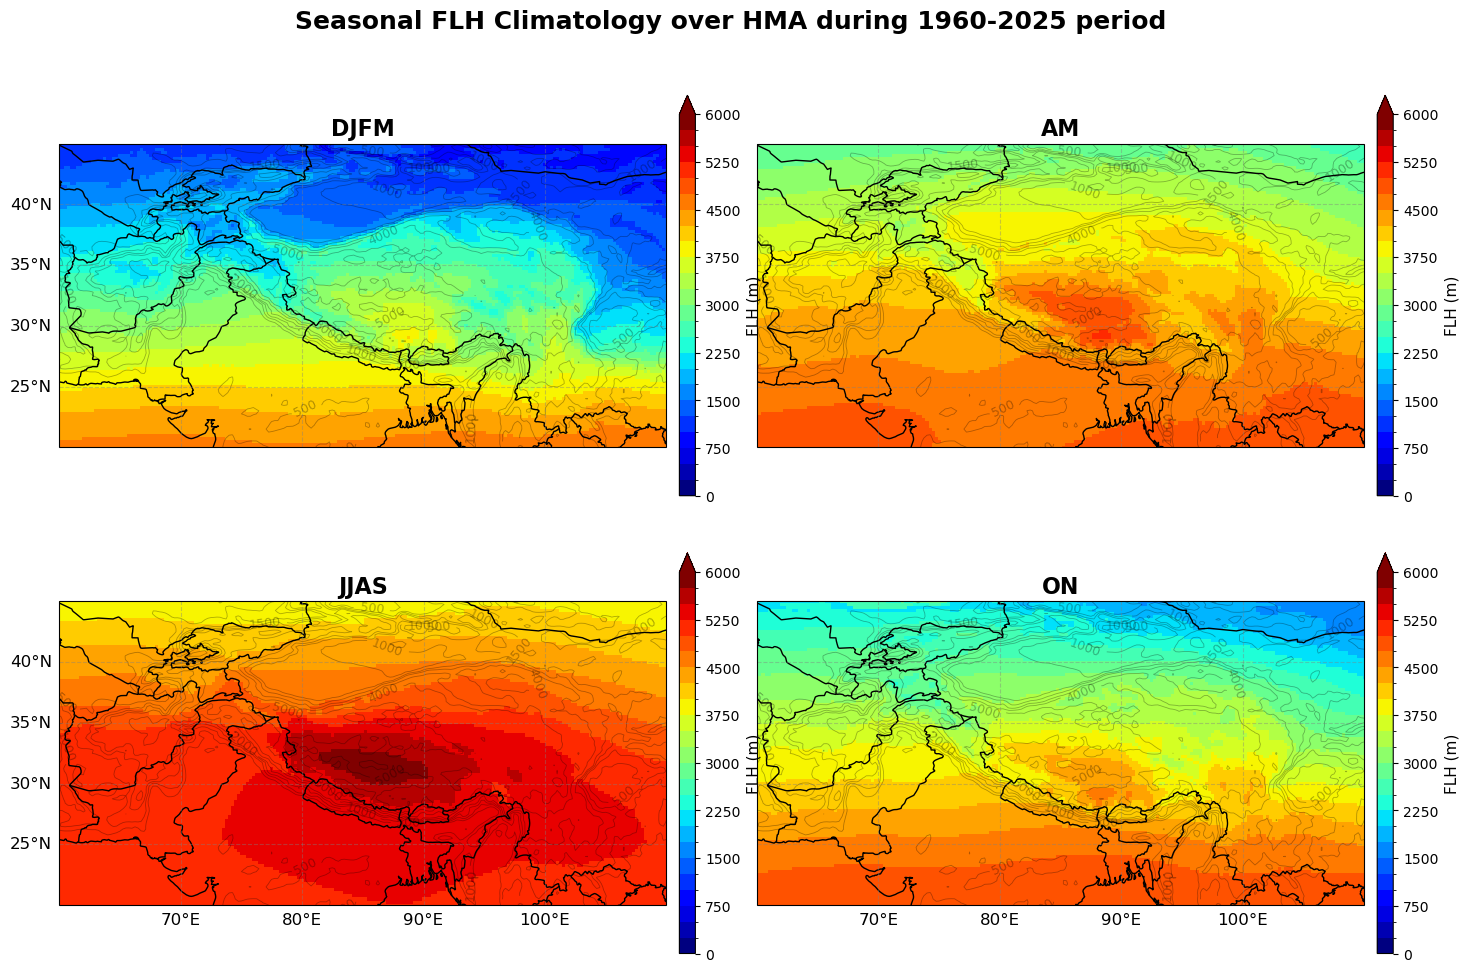

In [11]:
#==============  Colorbar for each season  ===============================

seasons = ["DJFM", "AM", "JJAS", "ON"]

vmin_dict = 0
vmax_dict = {'DJFM': 6250,
        'AM': 6250,
        'JJAS': 6250,
        'ON': 6250}

elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = clim_dict[season]['FLH']

    vmin = vmin_dict
    vmax = vmax_dict[season]
    #vmax = float(data_season.max())
    levels = np.arange(vmin, vmax, 250)
    cmap = plt.get_cmap("jet")
    norm = mcolors.BoundaryNorm(levels, cmap.N)
    
    im = ax.pcolormesh(data_season.lon,data_season.lat,data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.lon.min()),
        float(tcwv_mean.lon.max()),
        float(tcwv_mean.lat.min()),
        float(tcwv_mean.lat.max())
    ], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,1500,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.7, fraction=0.04, aspect=25, extend='max')
    cbar.set_label("FLH (m)", fontsize=11)
    cbar.ax.tick_params(labelsize=10)

fig.subplots_adjust(left=0.08, right=0.92, top=0.98, bottom=-0.05, wspace=0.08, hspace=-0.2)
plt.suptitle(f"Seasonal FLH Climatology over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'seasonal_tcwv_clim_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Annual Trend of tcwv

In [12]:
tcwv_annual,_ = seasonal_selection(tcwv_MA['FLH'], 'JFMAMJJASOND', iyear, fyear)
par = trend_vect(tcwv_annual.time,tcwv_annual,dim='time')
trend = par[0] *10;p = par[3]

60


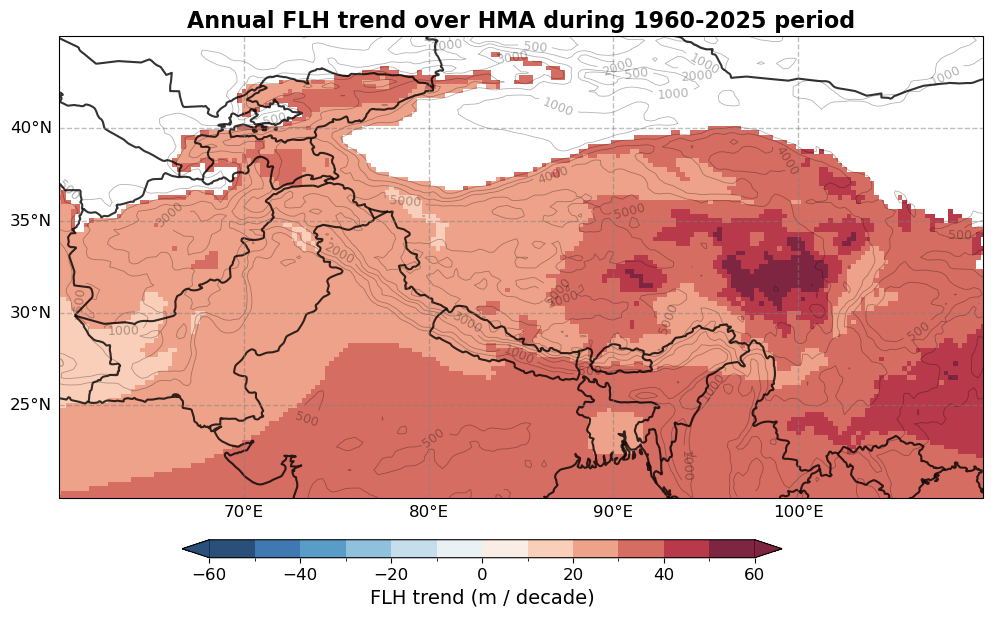

In [13]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

step = 10
vmax = 60
#vmax = round(float(np.abs(trend.max().values)), 2)
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu_r", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

pcm = ax.pcolormesh(trend['lon'],trend['lat'],trend,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(), alpha=0.85)

#Map limitations
ax.set_extent([
    float(tcwv_mean.lon.min()),
    float(tcwv_mean.lon.max()),
    float(tcwv_mean.lat.min()),
    float(tcwv_mean.lat.max())
], crs=ccrs.PlateCarree())

sig = p > 0.05   # significativity threshold
step = 2  # for stepping the points on the map that appears. 1 point out of 2 on every direction.
#ax.contourf(trend['longitude'],trend['latitude'],sig,levels=[0.5, 1],hatches=['///'],colors='none',transform=ccrs.PlateCarree())
lon_sig, lat_sig = trend['lon'].values, trend['lat'].values
lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
          color='black', s=1, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.5)

ax.coastlines(linewidth=1.5, alpha = 0.8)
ax.add_feature(cfeature.BORDERS, linewidth=1.5, alpha = 0.8)

elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.23, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("FLH trend (m / decade)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.set_title(f"Annual FLH trend over {dom} during {iyear}-{fyear} period", fontsize=16, weight='bold')

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Trends of tcwv

In [18]:
seasons = [1,2,3,4,5,6,7,8,9,10,11,12]
start_year = iyear
end_year = fyear
trend_dict = {}
p_dict = {}

#Climatology for each season
for season in seasons:
    tcwv_season,_ = monthly_selection(tcwv_MA['FLH'], season, start_year, end_year)
    par = trend_vect(tcwv_season.time.dt.year,tcwv_season,dim='time')
    trend_season = par[0] * 10;p_season = par[3]
    trend_dict[season] = trend_season
    p_dict[season] = p_season

70


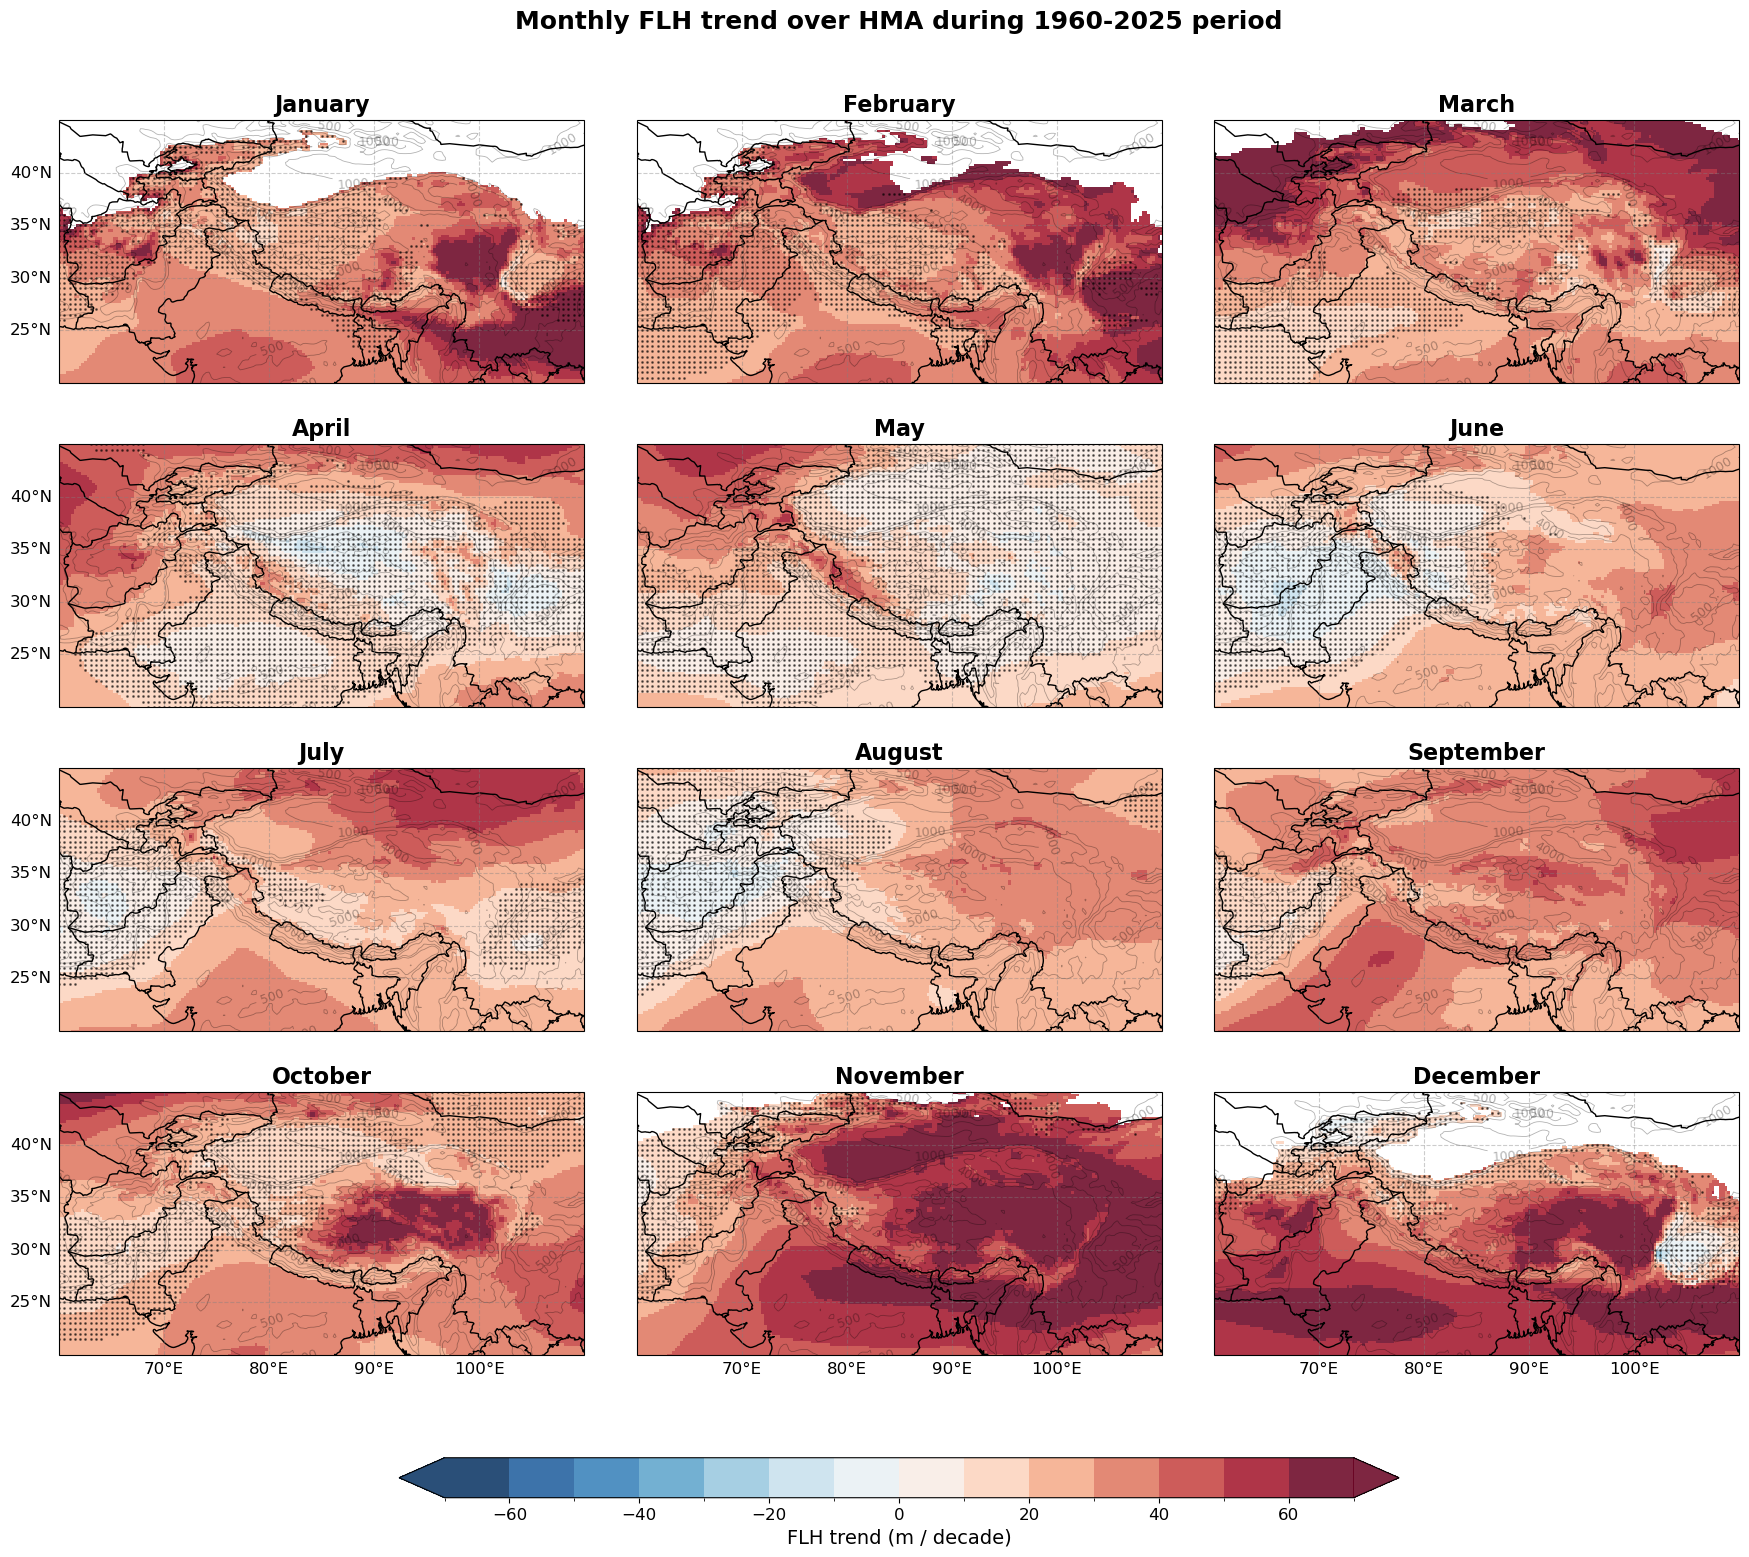

In [19]:
seasons_str = ["January", "February", "March", "April",
                "May", "June", "July", "August",
                "September", "October", "November", "December"]
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

step = 10
vmax = 70
#vmax = round(max(float(np.abs(ds.max().values)) for ds in trend_dict.values()), 2)
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu_r", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(4, 3, figsize=(20, 16), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_dict[season]

    im = ax.pcolormesh(data_season['lon'],data_season['lat'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.lon.min()),
        float(tcwv_mean.lon.max()),
        float(tcwv_mean.lat.min()),
        float(tcwv_mean.lat.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p_dict[season] > 0.05   
    step = 2
    lon_sig, lat_sig = data_season['lon'].values, data_season['lat'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=1, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha = 0.5)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(seasons_str[i], fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("FLH trend (m / decade)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Monthly FLH trend over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Trends of IVT

In [7]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
trend_dict = {}
p_dict = {}

#Climatology for each season
for season in seasons:
    tcwv_season,_ = seasonal_selection(tcwv_MA['FLH'], season, start_year, end_year)
    par = trend_vect_na(tcwv_season.time,tcwv_season,dim='time')
    trend_season = par[0]*10;p_season = par[3]
    trend_dict[season] = trend_season
    p_dict[season] = p_season

(D- 1960  JF- 1961  to D- 2025 JF- 2026


70


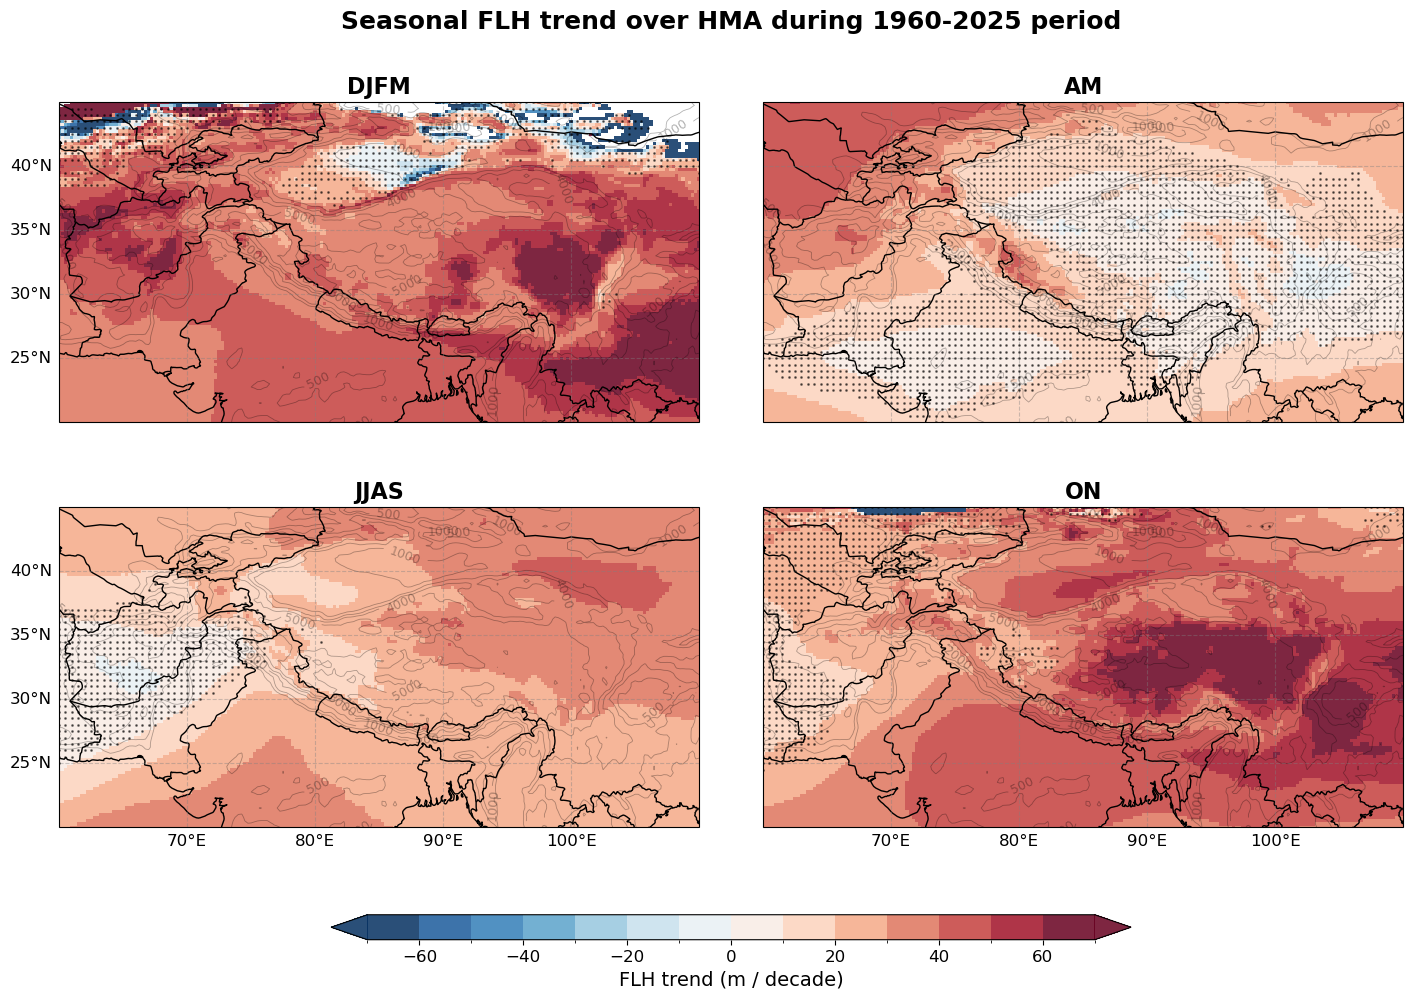

In [8]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
step = 10
vmax = 70
#vmax = round(max(float(np.abs(ds.max().values)) for ds in trend_dict.values()), 2)
print(vmax)
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("RdBu_r", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_dict[season]

    im = ax.pcolormesh(data_season['lon'],data_season['lat'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.lon.min()),
        float(tcwv_mean.lon.max()),
        float(tcwv_mean.lat.min()),
        float(tcwv_mean.lat.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p_dict[season] > 0.05   
    step = 2
    lon_sig, lat_sig = data_season['lon'].values, data_season['lat'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=1, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.5)

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("FLH trend (m / decade)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal FLH trend over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()